In [ ]:
# Kütüphaneler ve yardımcı modüller
# - NumPy / Matplotlib: veri işleme ve görselleştirme
# - tqdm: eğitim ilerleme çubuğu
# - yaml: konfigürasyon dosyası okuma
# - sklearn: veri bölme (train/test)
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm, trange
import yaml
from sklearn.model_selection import train_test_split

# PyTorch temel importları
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Model ve dataset tanımları
# `NARX_Transformer` model sınıfı `model.py` içinde; yapılandırma parametreleri config.yaml'dan alınır.
from model import NARX_Transformer
from dataset import load_raw_data, BatteryDataset

# Konfigürasyon dosyasını yükle
# Bu dosyada `NUM_CYCLES`, `FEATURE_DIM1/2`, `NUM_ATTENTION`, `EPOCHS` vb. ayarlar bulunur
with open('config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

# Konfigürasyon değerlerini değişkenlere al
NUM_CYCLES = cfg['NUM_CYCLES']
NUM_PREDS = cfg.get('NUM_PREDS', cfg.get('NUM_PRED', 1))
FEATURE_DIM1 = cfg['FEATURE_DIM1']
FEATURE_DIM2 = cfg['FEATURE_DIM2']
NUM_ATTENTION = cfg['NUM_ATTENTION']
EPOCHS = cfg['EPOCHS']
LEARNING_RATE = cfg['LEARNING_RATE']
BATCH_SIZE = cfg['BATCH_SIZE']

# Cihaz seçimi: GPU varsa kullan, yoksa CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Veriyi ham olarak yükle
# `load_raw_data` fonksiyonu ham bir sözlük döndürür: {battery_id: {'data': ..., 'cap': ...}, ...}
battery_dict = load_raw_data(folder='NASA_DATA', scale_data=True)

# Belirli bir bataryayı (ör: B0018) hariç tutmak istiyorsanız burada filtreleyin
# Bu örnekte B0018 veri setten çıkarılıyor çünkü bozuk/eksik olabilir
battery_dict_no18 = {key: val for key, val in battery_dict.items() if key != 'B0018'}

# `BatteryDataset` için beklenen formatı oluşturun
# Her öğe: [battery_type, sequence_of_features, sequence_of_capacities]
battery_data = []
for battery_type in battery_dict_no18:
    # Her batarya için kayan pencereler oluşturuyoruz (num_cycles uzunluğunda)
    for i in range(len(battery_dict_no18[battery_type]['data'])-NUM_CYCLES+1):
        sequences = battery_dict_no18[battery_type]['data'][i:i+NUM_CYCLES]
        capacities = battery_dict_no18[battery_type]['cap'][i:i+NUM_CYCLES]
        battery_data.append([battery_type, sequences, capacities])

# Wrap into Dataset objesi (Dataset içindeki `battery_data` alanını kullanırız)
dataset = BatteryDataset(battery_data)

# Train/test split: sklearn'in `train_test_split` ile rastgele bölüyoruz
# Bu, liste/array üzerinde çalışır ve iki Dataset parçacığı döndürür
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

# DataLoader'lar: minibatch ve shuffle işlemleri
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Model örneklendirme - parametrelerin anlamı:
# - feature_dim1/2: konvolüsyon/encoder boyutları
# - num_attention: transformer başlık sayısı / model boyutu
# - num_cycles: geçmiş döngü sayısı (input pencere uzunluğu)
# - num_preds: ileriye kaç adım tahmin edileceği (pred sequence uzunluğu)
model = NARX_Transformer(feature_dim1=FEATURE_DIM1, 
                         feature_dim2=FEATURE_DIM2, 
                         num_attention=NUM_ATTENTION, 
                         num_cycles=NUM_CYCLES, 
                         num_preds=NUM_PREDS).to(device)

# Kayıp fonksiyonu ve optimizer
# MSE veya MAE kullanabilirsiniz; burada MSELoss kullanılıyor (regresyon problemi)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Eğitim döngüsü hazırlığı
# `teacher forcing` tarzı: model'e geçmiş kapasite dizilerini verip bir sonraki değeri tahmin ettiriyoruz
best_loss = float('inf')
model.train()

# Eğitim döngüsü: epoch başına
# - Her batch'te model(inputs, outputs[:,:-1]) çağrılıyor; burada outputs[:,:-1] geçmiş kapasiteleri temsil eder
# - loss, son döngü (outputs[:,-1]) ile karşılaştırılır
# Not: Bu yaklaşım tek adımlık tahmin eğitimidir; çok-adımlı serbest çalışma için farklı eğitim stratejileri gerekir
t_range = trange(EPOCHS)
for epoch in t_range:
    train_losses = []
    for inputs, outputs in train_dataloader:
        # inputs: (batch, num_cycles, feature_dim) veya dataset'e göre farklı bir düzen olabilir
        inputs = inputs.float().to(device)
        outputs = outputs.float().to(device)

        # Model çağrısı: geçmiş kapasiteler (outputs[:,:-1]) teacher-forcing olarak veriliyor
        predicted_outputs = model(inputs, outputs[:,:-1])

        optimizer.zero_grad()
        # Kayıp: tahmin edilen son kapasite ile gerçek son kapasite karşılaştırması
        loss = criterion(predicted_outputs, outputs[:,-1].unsqueeze(-1))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Test/val hesaplaması (evaluation)
    test_losses = []
    for inputs, outputs in test_dataloader:
        inputs = inputs.float().to(device)
        outputs = outputs.float().to(device)
        with torch.no_grad():
            predicted_outputs = model(inputs, outputs[:,:-1])
            test_loss = criterion(predicted_outputs, outputs[:,-1].unsqueeze(-1))
            test_losses.append(test_loss.item())

    # Eğitim ilerleme bilgisi gösterimi
    t_range.set_description(f"train loss: {np.mean(train_losses)}, test loss: {np.mean(test_losses)}")
    t_range.refresh()

    # En iyi model kaydediliyor
    if np.mean(test_losses) < best_loss:
        best_loss = np.mean(test_losses)
        torch.save(model, 'trained_model.pt')

cuda


train loss: 0.0006627626617524871, test loss: 0.0006626264686929062:   2%|▏         | 45/2000 [01:01<44:23,  1.36s/it]


KeyboardInterrupt: 

In [ ]:
# Test/plot hücresi: test kümesi üzerinden model çıktıları ve gerçek etiketleri toplanıp çiziliyor
# - `soh_labels`: gerçek SoH (State of Health) değerleri
# - `soh_preds`: modelin tahminleri
# Bu grafik tek adımlık tahminleri gösterir (her örnek için son döngü tahmini)
soh_labels = []
soh_preds = []
for inputs, outputs in test_dataloader:
    inputs = inputs.float().to(device)
    outputs = outputs.float().to(device)
    with torch.no_grad():
        # Model çağrısı (teacher-forcing geçmiş kapasiteler veriliyor)
        predicted_outputs = model(inputs, outputs[:,:-1])
        # outputs[:,-1] gerçek son SoH değeridir
        soh_labels.append(outputs[:,-1].cpu().numpy().ravel())
        soh_preds.append(predicted_outputs.cpu().numpy().ravel())

# Bütün batch'lerden gelen dizileri yatay olarak birleştir
soh_labels = np.hstack(soh_labels)
soh_preds = np.hstack(soh_preds)

# Basit zaman serisi çizimi: gerçek ve tahmin
plt.figure(figsize=(10,5))
plt.plot(soh_labels)
plt.plot(soh_preds)
plt.grid()
plt.legend(['label','pred'])
# Not: çizimler modelin tek-adımlık tahminlerini gösterir; ardışık (multi-step) tahmin için farklı bir fonksiyon kullanılır

NameError: name 'test_dataloader' is not defined

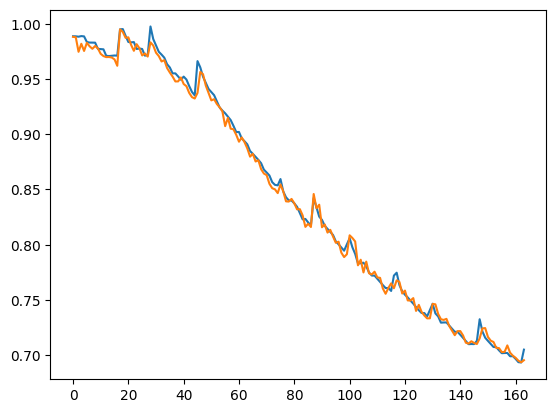

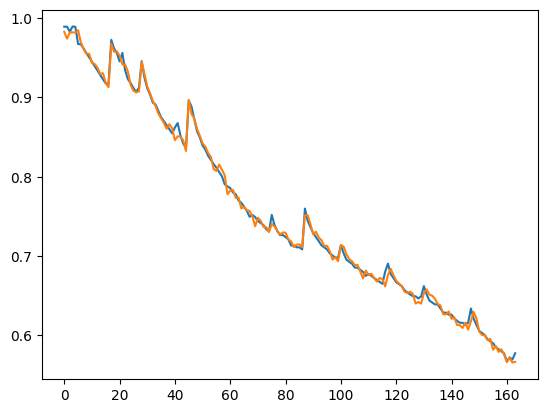

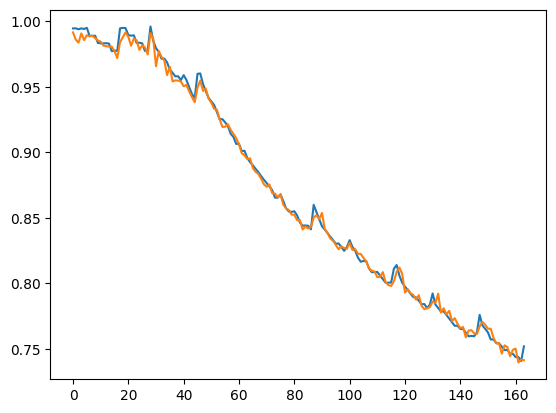

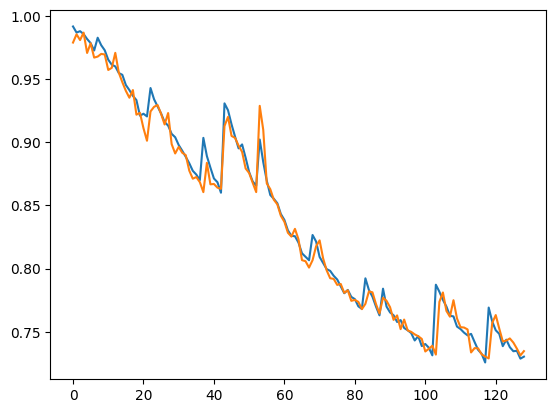

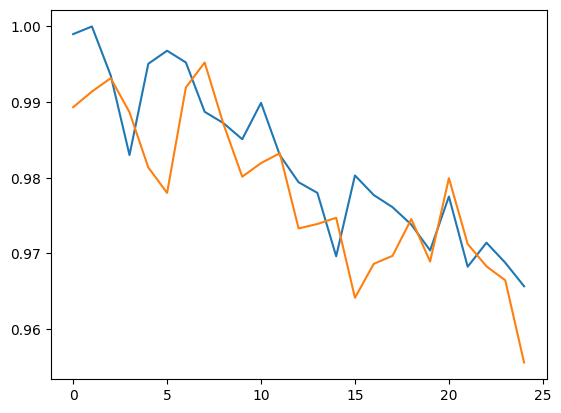

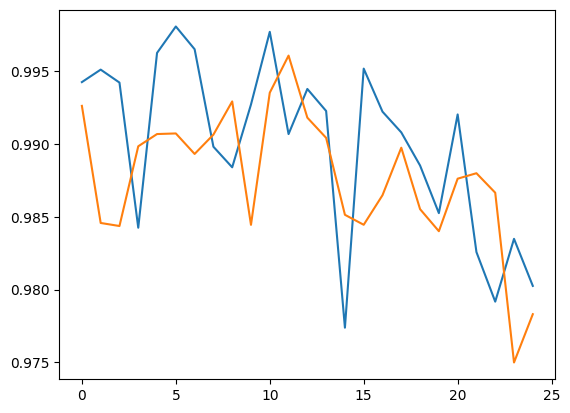

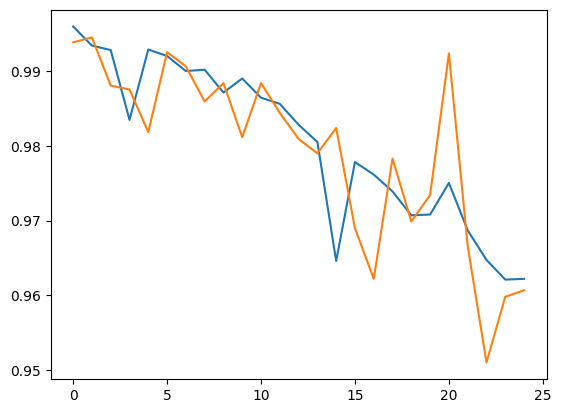

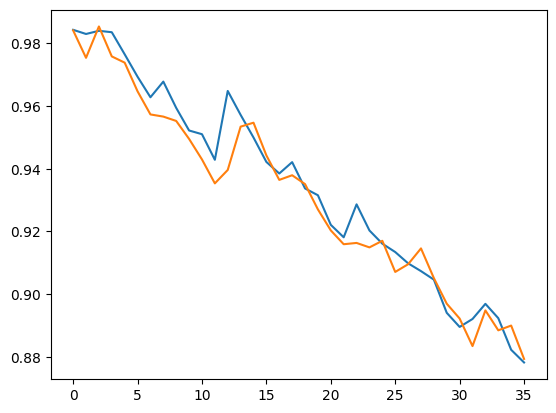

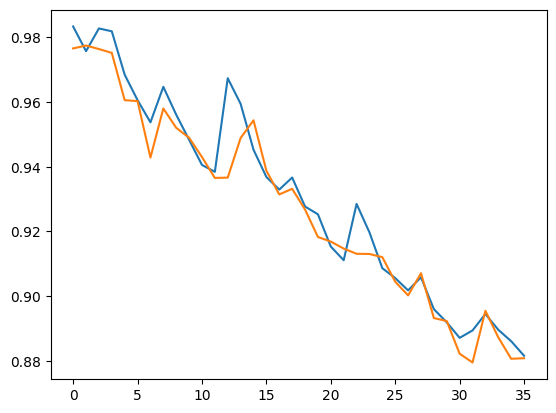

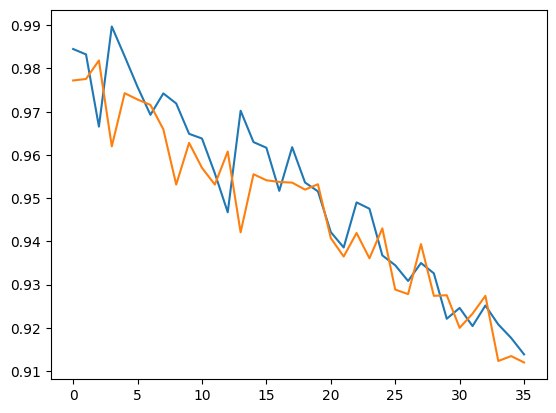

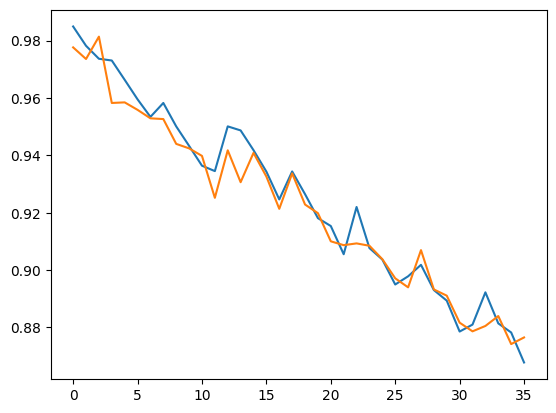

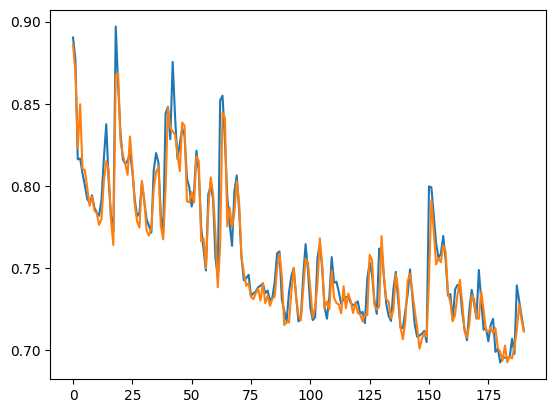

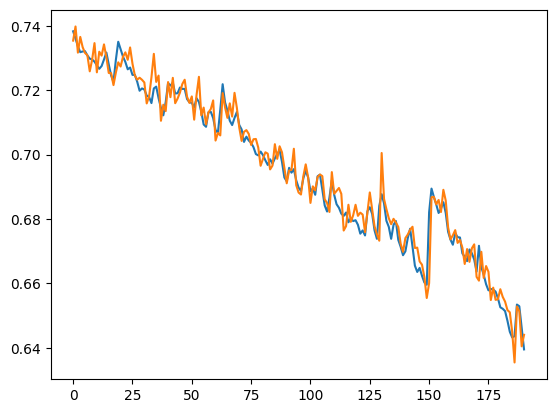

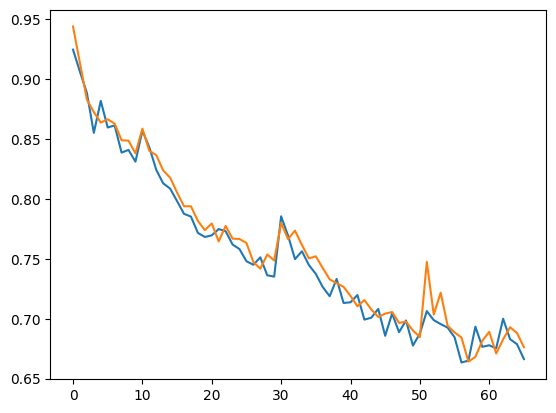

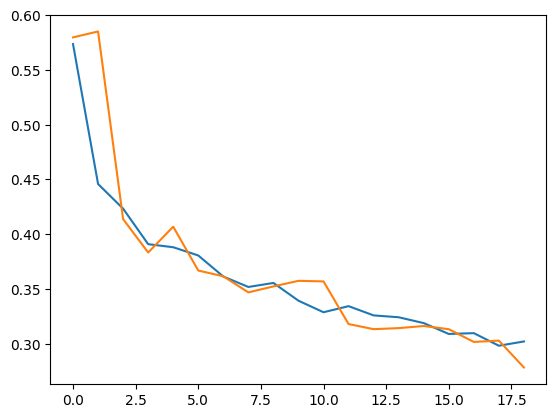

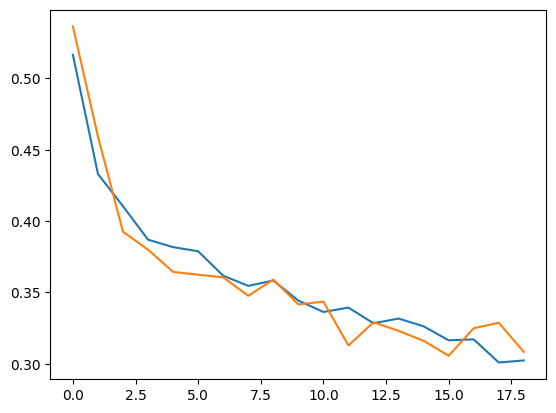

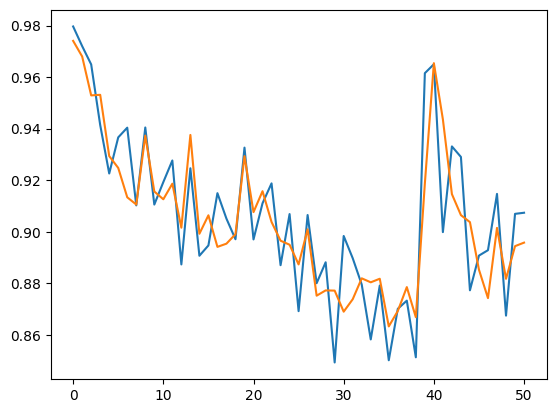

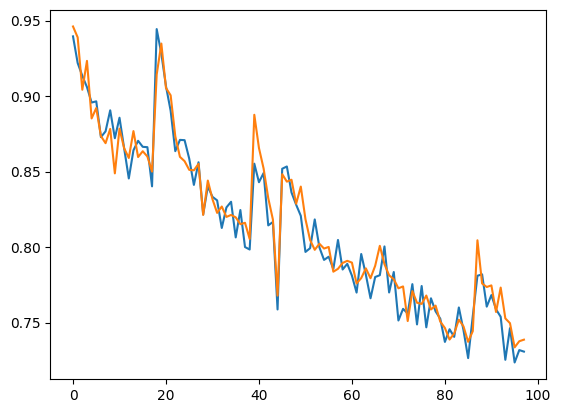

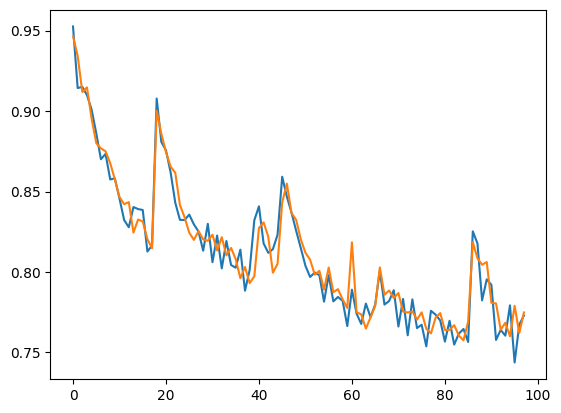

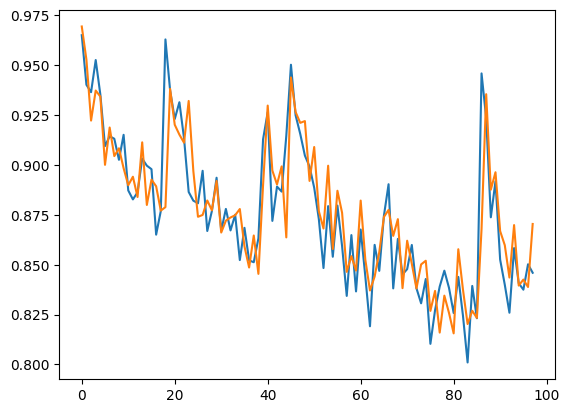

In [ ]:
# Bu fonksiyon batarya başına kapasite zaman serisini çizer ve modelin ardışık tahminlerini uygular
# - `model`: eğitimli NARX_Transformer model nesnesi
# - `battery_dict`: ham veri sözlüğü (load_raw_data tarafından üretilen format)
# - `num_cycles`: modelin girişte beklediği pencere uzunluğu
# Fonksiyon içinde her batarya için kayan pencere ile girişler hazırlanır, model çağrılır ve gerçek vs tahmin edilen SoH çizilir
model = torch.load('trained_model.pt')

def plot_capacity_sequence(model, device, battery_dict, num_cycles):
    for name in battery_dict:
        soh_labels = []
        soh_preds = []
        # ham veri ve kapasite dizisini al
        data, caps = battery_dict[name]['data'], battery_dict[name]['cap']
        # kayan pencere: veri dizisinden num_cycles uzunluğunda pencereler oluştur
        for i in range(len(data)-num_cycles):
            input_stream = data[i:i+num_cycles]
            # Gerçek etiket: pencerenin sonundaki kapasite
            soh_labels.append(caps[i+num_cycles-1])

            # Modelin beklediği tensör şekline dönüştür
            input_stream = torch.tensor(input_stream).unsqueeze(0).float().to(device)
            # Kapasite akışı: modelin ikinci argümanı olarak geçmiş kapasiteler veriliyor
            cap_stream = torch.tensor(caps[i:i+num_cycles-1]).unsqueeze(0).float().to(device)

            # Model çağrısı: tek adımlık tahmin (sonraki SoH)
            pred = model(input_stream, cap_stream)
            soh_preds.append(pred.cpu().detach().numpy())

        # NumPy dizilerine çevir ve çiz
        soh_labels = np.array(soh_labels).ravel()
        soh_preds = np.array(soh_preds).ravel()
        plt.plot(soh_labels)
        plt.plot(soh_preds)
        plt.show()

# Örnek çağrı: tüm bataryalar için num_cycles=3 ile çiz
plot_capacity_sequence(model, device, battery_dict, 3)

# battery health prediction for article

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm, trange
import yaml
import os
import seaborn as sns
sns.set_theme()

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from model import NARX_Transformer
from dataset import load_NASA

# Load the YAML configuration file
with open('config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

# # Access the variables
NUM_CYCLES = 3
NUM_PREDS = 7
FEATURE_DIM1 = cfg['FEATURE_DIM1']
FEATURE_DIM2 = cfg['FEATURE_DIM2']
NUM_ATTENTION = cfg['NUM_ATTENTION']
EPOCHS = cfg['EPOCHS']
LEARNING_RATE = cfg['LEARNING_RATE']
BATCH_SIZE = cfg['BATCH_SIZE']

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
train_dataset, test_dataset = load_NASA(folder='NASA_DATA', num_cycles=NUM_CYCLES+NUM_PREDS-1, split_ratio=0.3, scale_data=True)

# Train/test split
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# NN model
# model = NARX_Transformer(feature_dim1=FEATURE_DIM1, 
#                          feature_dim2=FEATURE_DIM2, 
#                          num_attention=NUM_ATTENTION, 
#                          num_cycles=NUM_CYCLES, 
#                          num_preds=NUM_PREDS).to(device)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('development/trained_model_0.015987_703.pt', map_location=device)

g:\git_projects\Battery-SoH-Transformer\dataset.py:46: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  battery_data = np.array(battery_data)


In [ ]:
def plot_predicted_capacity(model, train_dataset, test_dataset, num_cycles):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    battery_types = train_dataset.battery_data[:,0]

    for battery_type in np.unique(battery_types):
        train_data = train_dataset.battery_data[train_dataset.battery_data[:,0] == battery_type]
        test_data = test_dataset.battery_data[test_dataset.battery_data[:,0] == battery_type]
        
        train_caps = [c[-1] for c in train_data[:,-1]]
        test_caps = [c[-1] for c in test_data[:,-1]]
        pred_caps = [train_data[:,-1][i][-1] for i in np.arange(-num_cycles+1,0)]
        
        for cycle in range(len(test_data)):
            _, inputs, _ = test_data[cycle]
            inputs = torch.tensor(inputs[:num_cycles]).float().unsqueeze(0).to(device)
            outputs = torch.tensor(pred_caps[-num_cycles+1:]).float().unsqueeze(0).to(device)
            pred = model(inputs, outputs)
            pred_caps.append(pred.item())
        
        plt.plot(train_caps+[test_caps[0]])
        plt.plot(range(len(train_caps),len(train_caps)+len(test_caps)), test_caps, c='olive')
        plt.plot(range(len(train_caps),len(train_caps)+len(pred_caps)-num_cycles+1), pred_caps[num_cycles-1:], '--', c='red')
        plt.grid('on')
        plt.title(battery_type, fontsize=15)
        plt.legend(['_','Real data','Prediction'])
        plt.xlabel('Cycle Number')
        plt.ylabel('Battery SoH (%)')
        plt.show()

    # def pred_sequence(self, my_data, capacity):
    #     pred_caps = torch.stack([capacity[:,i] for i in range(self.num_cycles-1)], axis=-1)
    #     for cycle in range(self.num_preds):
    #         pred = self.forward(my_data[:,cycle:cycle+self.num_cycles], pred_caps[:,-self.num_cycles+1:])
    #         pred_caps = torch.cat([pred_caps, pred], axis=-1)
    #     return pred_caps

plot_predicted_capacity(model, train_dataset, test_dataset, NUM_CYCLES)

RuntimeError: Given groups=1, weight of size [6, 5, 3, 3], expected input[1, 3, 256, 3] to have 5 channels, but got 3 channels instead

### pred sequence

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm, trange
import yaml

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from model import NARX_Transformer
from dataset import load_NASA

# Load the YAML configuration file
with open('config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

# # Access the variables
NUM_CYCLES = cfg['NUM_CYCLES']
NUM_PREDS = cfg['NUM_PREDS']
FEATURE_DIM1 = cfg['FEATURE_DIM1']
FEATURE_DIM2 = cfg['FEATURE_DIM2']
NUM_ATTENTION = cfg['NUM_ATTENTION']
EPOCHS = cfg['EPOCHS']
LEARNING_RATE = cfg['LEARNING_RATE']
BATCH_SIZE = cfg['BATCH_SIZE']

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
train_dataset, test_dataset = load_NASA(folder='NASA_DATA', num_cycles=NUM_CYCLES+NUM_PREDS-1, split_ratio=0.3, scale_data=True)

# Train/test split
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

# NN model
model = NARX_Transformer(feature_dim1=FEATURE_DIM1, 
                         feature_dim2=FEATURE_DIM2, 
                         num_attention=NUM_ATTENTION, 
                         num_cycles=NUM_CYCLES, 
                         num_preds=NUM_PREDS).to(device)

/Users/amir-mac/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/amir-mac/Git-Projects/Battery-SoH-Transformer/dataset.py:46: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  battery_data = np.array(battery_data)


In [ ]:
for epoch in range(1):
    for inputs, outputs in train_dataloader:
        inputs = inputs.float()
        outputs = outputs.float()
        break

In [ ]:
inputs.shape, outputs.shape

(torch.Size([64, 9, 256, 3]), torch.Size([64, 9]))

In [ ]:
model.pred_sequence(inputs,outputs).shape

torch.Size([64, 9])

In [ ]:
pred_caps = torch.stack([outputs[:,0], outputs[:,1]], axis=-1)
pred_caps.shape

torch.Size([64, 2])

In [ ]:
inputs[:,cycle:cycle+num_cycles].shape

NameError: name 'cycle' is not defined

In [ ]:
cycle = 0
num_cycles = 3
pred = model(inputs[:,cycle:cycle+num_cycles], pred_caps[:,-num_cycles+1:])

In [ ]:
pred.shape

torch.Size([64, 1])

In [ ]:
torch.cat([pred_caps, pred], axis=-1).shape


torch.Size([64, 3])

In [ ]:
my_data = inputs
capacity = outputs

pred_caps = torch.stack([capacity[:,0], capacity[:,1]], axis=-1)
for cycle in range(model.num_preds):
    pred = model.forward(my_data[:,cycle:cycle+model.num_cycles], pred_caps[:,-model.num_cycles+1:])
    pred_caps = torch.cat([pred_caps, pred], axis=-1)
